In [1]:
# # Task 2: Exploratory Data Analysis

In [2]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv('../data/processed/ethiopia_fi_enriched.csv', parse_dates=['observation_date'])
print(f"Loaded {len(df)} records")
df.head()

Loaded 57 records


,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,unit,observation_date,period_start,period_end,fiscal_year,gender,location,region,source_name,source_type,source_url,confidence,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes,parent_id
0,REC_0001,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,22.0,NaN,percentage,%,2014-12-31,NaN,NaN,2014,all,national,NaN,Global Findex 2014,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Baseline year,NaN,NaN
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.0,NaN,percentage,%,2017-12-31,NaN,NaN,2017,all,national,NaN,Global Findex 2017,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,NaN,NaN,NaN
2,REC_0003,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,46.0,NaN,percentage,%,2021-12-31,NaN,NaN,2021,all,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,NaN,NaN,NaN
3,REC_0004,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,56.0,NaN,percentage,%,2021-12-31,NaN,NaN,2021,male,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Gender disaggregated,NaN,NaN
4,REC_0005,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,36.0,NaN,percentage,%,2021-12-31,NaN,NaN,2021,female,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Gender disaggregated,NaN,NaN


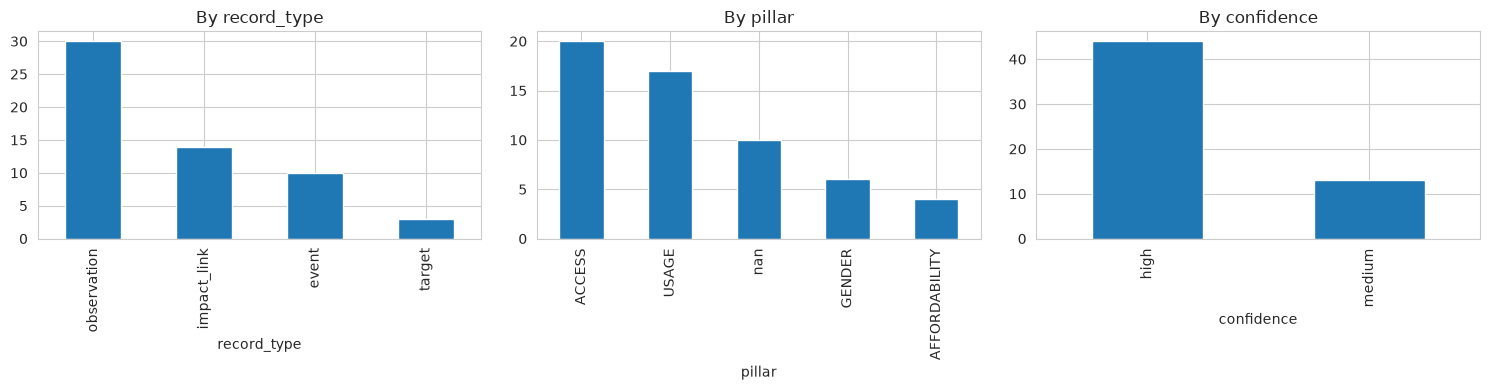

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df['record_type'].value_counts().plot(kind='bar', ax=axes[0], title='By record_type')
df['pillar'].value_counts(dropna=False).plot(kind='bar', ax=axes[1], title='By pillar')
df['confidence'].value_counts(dropna=False).plot(kind='bar', ax=axes[2], title='By confidence')
plt.tight_layout()
plt.show()

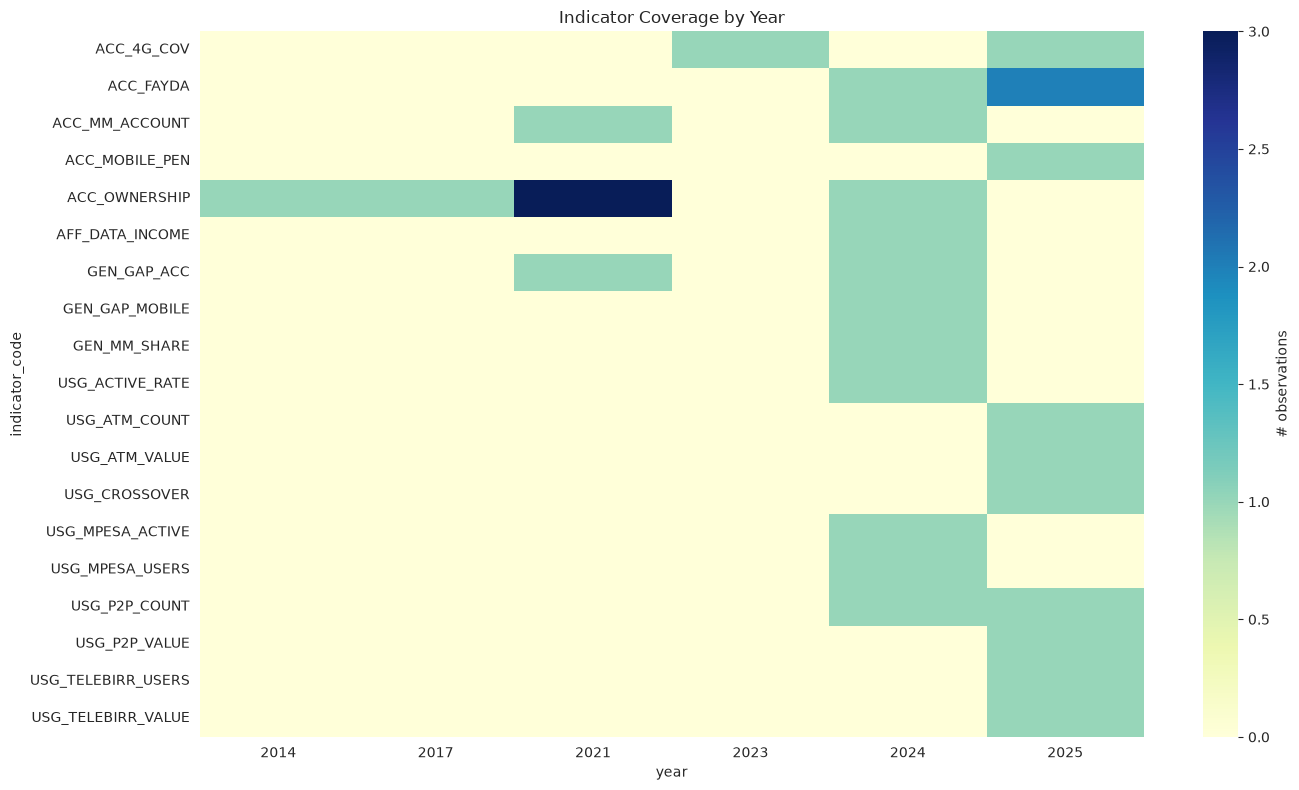

In [5]:
obs = df[df['record_type'] == 'observation'].copy()
obs['year'] = obs['observation_date'].dt.year
coverage = obs.groupby(['indicator_code', 'year']).size().unstack(fill_value=0)

plt.figure(figsize=(14, 8))
sns.heatmap(coverage, cmap='YlGnBu', cbar_kws={'label': '# observations'})
plt.title('Indicator Coverage by Year')
plt.tight_layout()
plt.show()

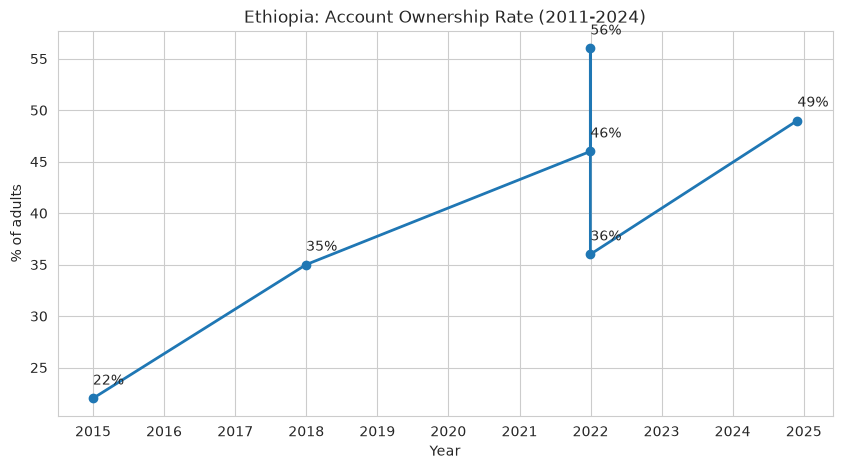

In [6]:
access = obs[obs['indicator_code'] == 'ACC_OWNERSHIP'].sort_values('observation_date')

plt.figure(figsize=(10, 5))
plt.plot(access['observation_date'], access['value_numeric'], marker='o', linewidth=2)
for _, row in access.iterrows():
    plt.annotate(f"{row['value_numeric']:.0f}%",
                 (row['observation_date'], row['value_numeric']),
                 textcoords="offset points", xytext=(0, 10))
plt.title('Ethiopia: Account Ownership Rate (2011-2024)')
plt.ylabel('% of adults')
plt.xlabel('Year')
plt.show()


In [7]:
access['pp_change'] = access['value_numeric'].diff()
access[['observation_date', 'value_numeric', 'pp_change']]


,observation_date,value_numeric,pp_change
0,2014-12-31,22.0,NaN
1,2017-12-31,35.0,13.0
2,2021-12-31,46.0,11.0
3,2021-12-31,56.0,10.0
4,2021-12-31,36.0,-20.0
5,2024-11-29,49.0,13.0


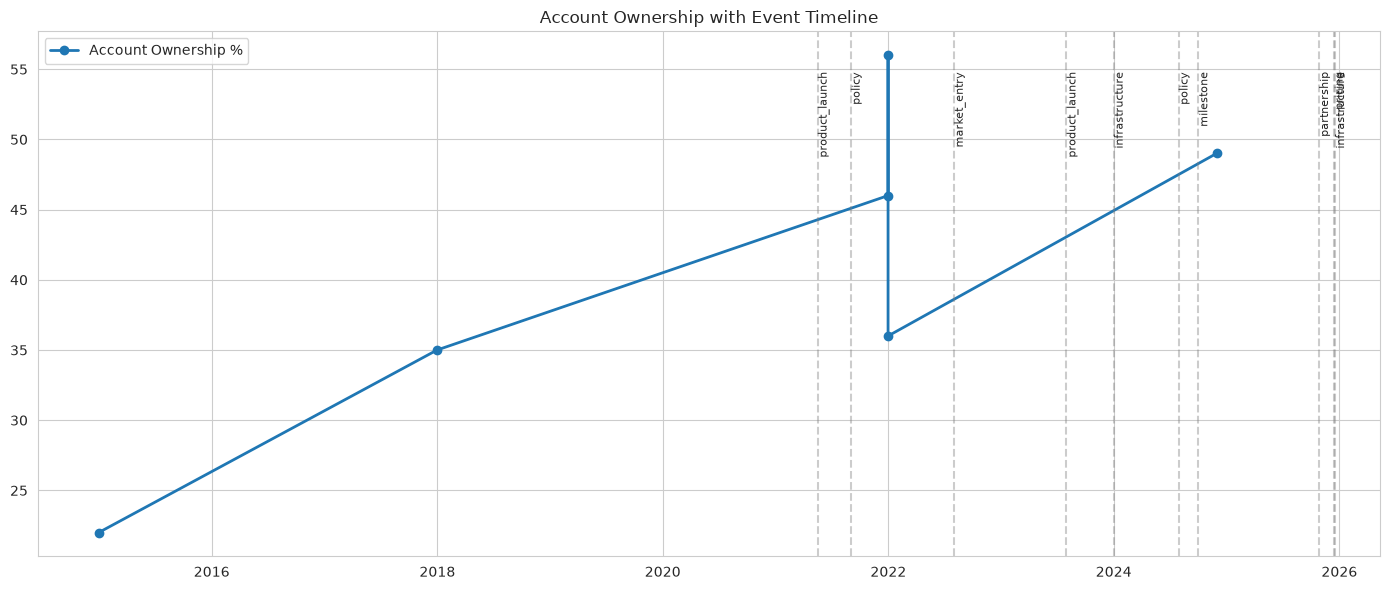

In [8]:
events = df[df['record_type'] == 'event'].sort_values('observation_date')

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(access['observation_date'], access['value_numeric'], marker='o', linewidth=2, label='Account Ownership %')
for _, ev in events.iterrows():
    ax.axvline(ev['observation_date'], color='gray', linestyle='--', alpha=0.4)
    ax.text(ev['observation_date'], ax.get_ylim()[1]*0.95, ev['category'],
            rotation=90, fontsize=8, va='top')
ax.set_title('Account Ownership with Event Timeline')
ax.legend()
plt.tight_layout()
plt.show()


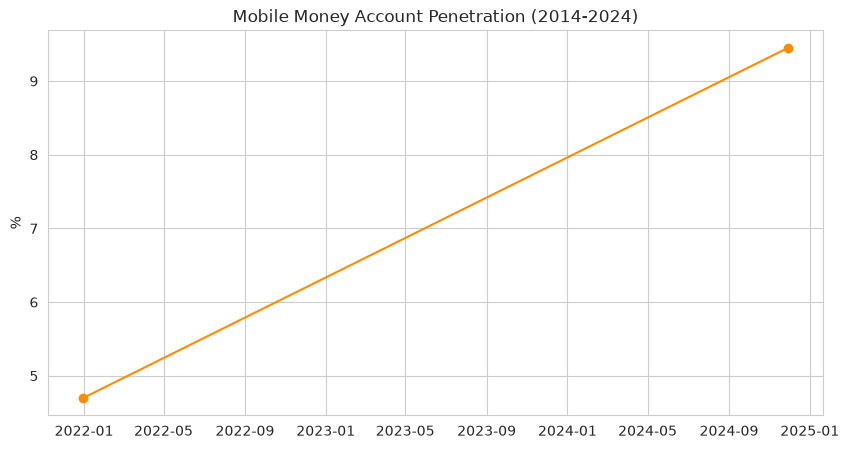

In [9]:
mm = obs[obs['indicator_code'] == 'ACC_MM_ACCOUNT'].sort_values('observation_date')
plt.figure(figsize=(10, 5))
plt.plot(mm['observation_date'], mm['value_numeric'], marker='o', color='darkorange')
plt.title('Mobile Money Account Penetration (2014-2024)')
plt.ylabel('%')
plt.show()

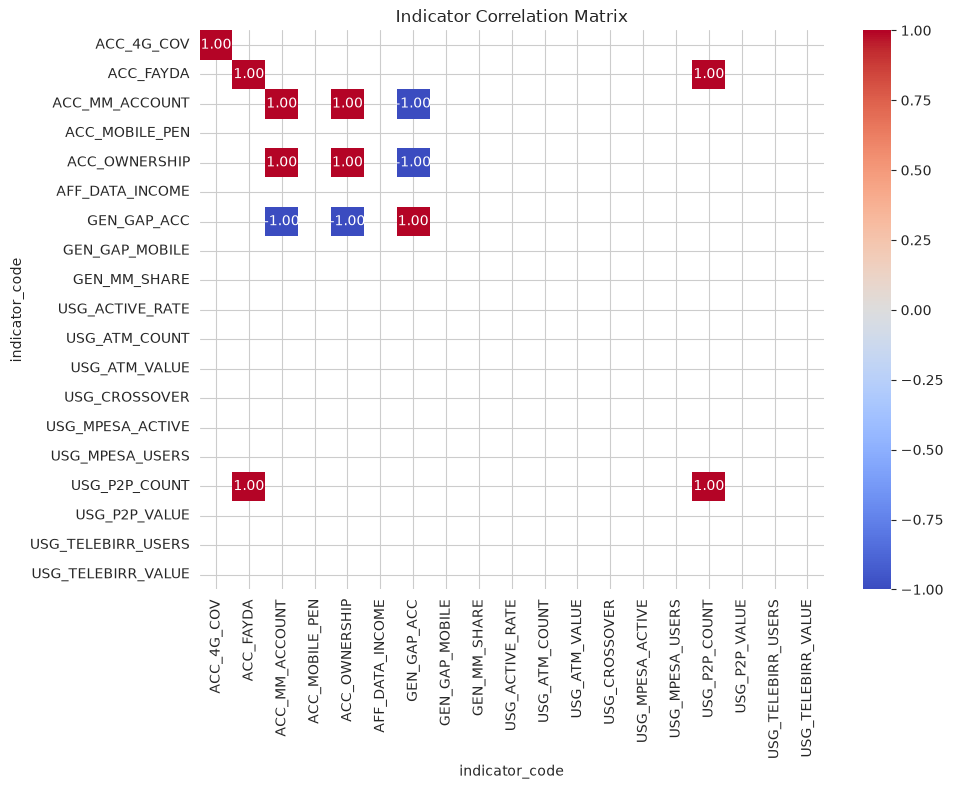

In [10]:
pivot = obs.pivot_table(index='year', columns='indicator_code', values='value_numeric', aggfunc='mean')
corr = pivot.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Indicator Correlation Matrix')
plt.tight_layout()
plt.show()